<a href="https://colab.research.google.com/github/Tej25-25/Tejaswini/blob/main/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load your file
data = pd.read_excel("sps_dataset_300.xlsx")

print(data.head())

   pump_power  temperature  detuning      g2  brightness
0       4.058       285.71     1.392  0.5777      695.01
1       1.982        26.84     2.197  0.2181      406.23
2       0.696       291.27     1.995  0.5547       14.64
3       2.242        98.23     0.149  0.2253      954.35
4       6.313        50.45    -1.247  0.2682     2008.77


In [ ]:
X = data[['pump_power', 'temperature', 'detuning']]
y = data[['g2', 'brightness']]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 25673.80601083263
R2 Score: 0.88628942522215


In [ ]:
# Example input
sample = [[5.0, 50, 0.2]]

prediction = model.predict(sample)

print("Predicted g2:", prediction[0][0])
print("Predicted brightness:", prediction[0][1])

Predicted g2: 0.2375649999999997
Predicted brightness: 2389.9062500000014


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


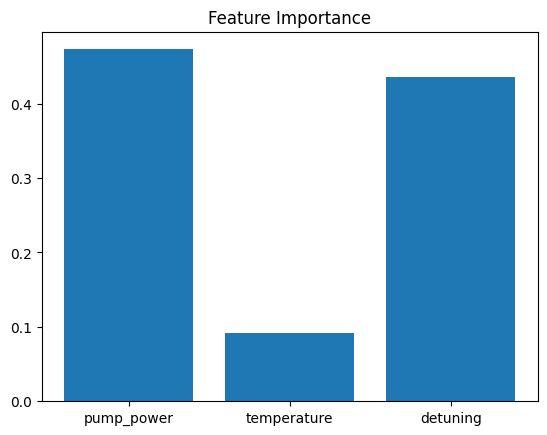

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

plt.scatter(y_test['g2'], y_pred[:,0])
plt.xlabel("Actual g2")
plt.ylabel("Predicted g2")
plt.title("g2 Prediction")
plt.show()

plt.scatter(y_test['brightness'], y_pred[:,1])
plt.xlabel("Actual Brightness")
plt.ylabel("Predicted Brightness")
plt.title("Brightness Prediction")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [ ]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

print("Tuned R2 Score:", r2_score(y_test, y_pred))

Tuned R2 Score: 0.8876628679602032


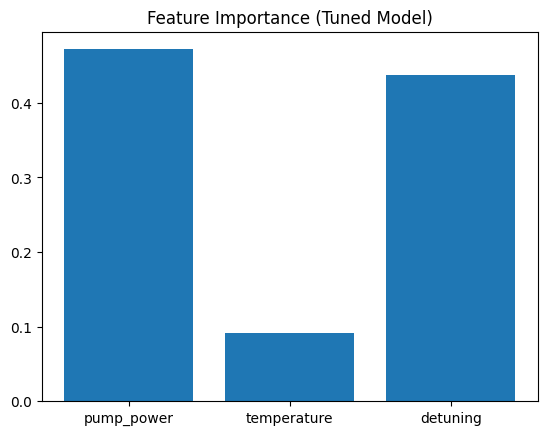

In [ ]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance (Tuned Model)")
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': np.arange(100, 500, 50),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': np.int64(350), 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


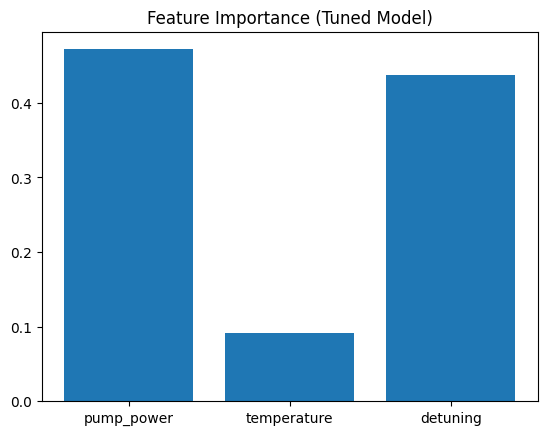

In [ ]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance (Tuned Model)")
plt.show()